In [768]:
import random as rd
import matplotlib.pyplot as plt
import numpy as np
import numbers
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from numpy import linspace, zeros
from csaps import CubicSmoothingSpline
from scipy.ndimage.filters import gaussian_filter1d


def logistic_growth(t, k):
    """
    Logistic growth function.
    
    Parameters:
    - t: Time steps.
    - L: The curve's maximum value (carrying capacity).
    - k: The growth rate.
    - x0: The x-value of the sigmoid's midpoint.
    
    Returns:
    - Logistic growth values at each time step.
    """
    return 1 / (1 + np.exp(-k * (t)))

def logistic_stimuli(x0,dt,T,s,r,A,t0=0,stimuli=None,noise_var=0,return_stimuli_bool=False):

    f = lambda u, t, r: r*(1 - u/A)*u
    f_s = lambda u, t, r, s: (r*s)*(1 - u/A)*u

    N_t = int(round(float(T)/dt))
    u = zeros(N_t+1)
    t = linspace(0, N_t*dt, len(u))
    t = t + t0

    if stimuli == False:
        stimuli = [False]*len(u)
    if stimuli == True:
        stimuli = [True]*len(u)
    if type(stimuli) == list:
        if len(stimuli) == 1:
            index = min(range(len(t)), key=lambda i: abs(t[i]-stimuli[0]))
            stimuli = [False]*len(u)
            stimuli[index] = True
        elif len(stimuli) == 2:
            index_min = min(range(len(t)), key=lambda i: abs(t[i]-stimuli[0]))
            if stimuli[1] == None:
                index_max = len(u)
            else:
                index_max = min(range(len(t)), key=lambda i: abs(t[i]-stimuli[1]))
            stimuli = [False]*len(u)
            stimuli[index_min:index_max+1] = [True]*(index_max-index_min)

    if isinstance(r, numbers.Number):
        r = [r]*len(u)

    if isinstance(s, numbers.Number):
        s = [s]*len(u)
    

    u, t, stimuli_applied = ode_FE(f=f,f_s=f_s,x0=x0,dt=dt,u=u,t=t,r=r,s=s,N_t=N_t,stimuli=stimuli)

    noise = np.random.normal(0,noise_var,len(u))
    u = u #+ noise
    
    if return_stimuli_bool:
        return u,t, stimuli_applied,stimuli
    else:
        return u,t, stimuli_applied

def ode_FE(f,f_s,x0,dt,u,t,r,s,N_t,stimuli):
    #print("n","t","dxdt","r","s","apply stimuly")
    u[0] = x0
    stimuli_applied = []
    for n in range(N_t):
        if stimuli[n]:
            u[n+1] = u[n] + dt*f_s(u[n], t[n], r[n],s[n])
            stimuli_applied.append(r[n] + s[n])
        else:
            u[n+1] = u[n] + dt*f(u[n], t[n], r[n])
            stimuli_applied.append(r[n])
        
        #print(f_s(u[n], t[n], r[n],s[n]))
        #print(n,round(u[n+1]-u[n],5),r[n],s[n],stimuli[n],t[n])
        #print(n,t[n],round(u[n+1]-u[n],5),r[n])

    return u, t, stimuli_applied

PYTHON_PATH = "/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/altricial_brain_vocal_learning"

In [769]:
SPECIES = "Marmoset"
COLOR = "orange"

df_events = pd.read_excel("{0}/data/developmental_stages_events.xlsx".format(PYTHON_PATH),index_col=False)
df_events = df_events[df_events.species == SPECIES]
gestation_days = df_events[df_events.event == "gestation"]["avg_wkspc"].values[0]*7
gestation_days_sd = df_events[df_events.event == "gestation"]["sd_(days)"].values[0]


In [770]:
dt = 1 #day
T = 7*60 #number of weeks
A = 1
N_t = int(round(float(T)/dt))
u = zeros(N_t+1)

t_dev = linspace(0, N_t*dt, len(u))
t = linspace(0, N_t*dt, len(u))
t0 = gestation_days
t = t + t0

num_steps = len(u)

noise_var = 0.01

np.random.seed(1)


In [771]:
# Taking the marmoset curve as reference to create the altricial and precocial curves

df_fit = pd.read_pickle("{0}/data/derivatives_absolute_values.pkl".format(PYTHON_PATH)) 
df_fit.head()

,species,x_dydx,derivatives,derivatives_max,derivatives_peak_at_birth
0,Human,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[2.9063523811601044e-05, 0.000116254197109810...","[2.3651828252636165, 2.4537124870399794, 2.314...","[[0.04213766543979938, 0.043819868194812636, 0..."
1,Marmoset,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[-1.9202417433916708e-12, -1.9677592888456275...","[0.07671885155066072, 0.07662814289176767, 0.0...","[[0.04836649866750991, 0.04052219615758758, 0...."
2,Chimpanzee,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[7.146548966829869e-06, 2.8586360627969043e-0...","[1.342824054365991, 1.2125733607875304, 1.2988...","[[0.4833269916182769, 0.4859837230318031, 0.48..."
3,Rhesus,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[0.004075980354670605, 0.004174282631037585, ...","[0.8229322695128367, 0.8197453299257162, 0.812...","[[0.6087734901739831, 0.6307611815327768, 0.65..."


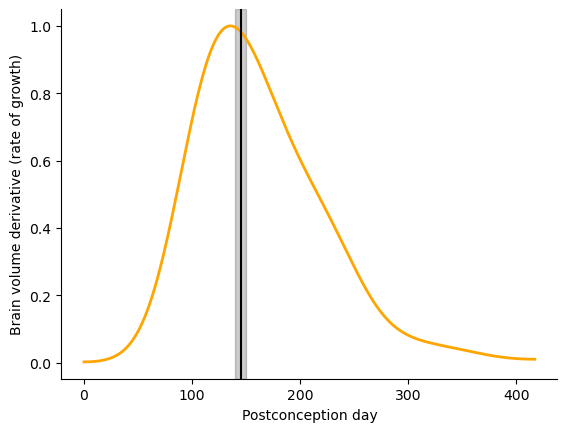

In [772]:
fig, ax = plt.subplots()
SPECIES = "Marmoset"
derivatives_dataset_species = df_fit[df_fit.species == SPECIES]

x = derivatives_dataset_species["x_dydx"].values[0]
all_devs = derivatives_dataset_species["derivatives"].values[0]


average_derivative = gaussian_filter1d(np.mean(np.array(all_devs), axis=0),sigma = 25)
low_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 25)
max_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 25)

x_fit = x
#y_error_max = max_95Percentil/np.max(max_95Percentil)
y_fit = average_derivative/np.max(average_derivative)
#y_error_min = low_95Percentil/np.max(max_95Percentil)


ax.plot(x_fit,y_fit, '-', color = COLOR,linewidth = 2)
#ax.fill_between(x_fit, y_error_min, y_error_max, color=COLOR, alpha=0.2)

ax.axvline(x = gestation_days, color = "black",linestyle = '-',label="birth")
ax.axvspan(gestation_days - gestation_days_sd, gestation_days + gestation_days_sd, alpha=0.2, color='black')


sns.despine()
plt.ylabel('Brain volume derivative (rate of growth)')
plt.xlabel('Postconception day')
plt.show()

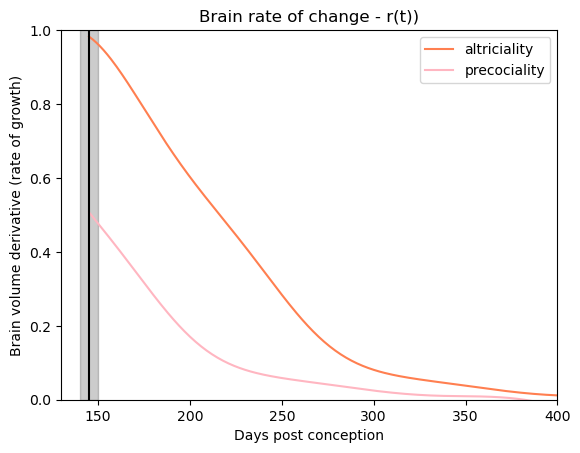

In [773]:
df_fit = pd.DataFrame({"x_fit":x_fit,"y_fit":y_fit})

#Creating the altricial curve
s = CubicSmoothingSpline(df_fit["x_fit"] - gestation_days, df_fit["y_fit"], normalizedsmooth=True).spline
dxdt = s(t_dev)
brain_plasticity_altricial = dxdt
plt.plot(t,brain_plasticity_altricial, color='coral',label = "altriciality")

#Creating the precocial curve curve
PRECOCIAL_SHIFT = 70
s = CubicSmoothingSpline(df_fit["x_fit"] - gestation_days - PRECOCIAL_SHIFT, df_fit["y_fit"], normalizedsmooth=True).spline
dxdt = s(t_dev)
brain_plasticity_precocial = dxdt
plt.plot(t,brain_plasticity_precocial, color='lightpink',label = "precociality")

plt.axvline(x = gestation_days, color = "black",linestyle = '-')
plt.axvspan(gestation_days - gestation_days_sd, gestation_days + gestation_days_sd, alpha=0.2, color='black')
plt.title("Brain rate of change - r(t))")
plt.ylabel('Brain volume derivative (rate of growth)')
plt.xlabel('Days post conception')
plt.ylim(0,1)
plt.xlim(130, 400)
plt.legend()
plt.savefig("{0}/figs/5B.pdf".format(PYTHON_PATH),dpi = 800)



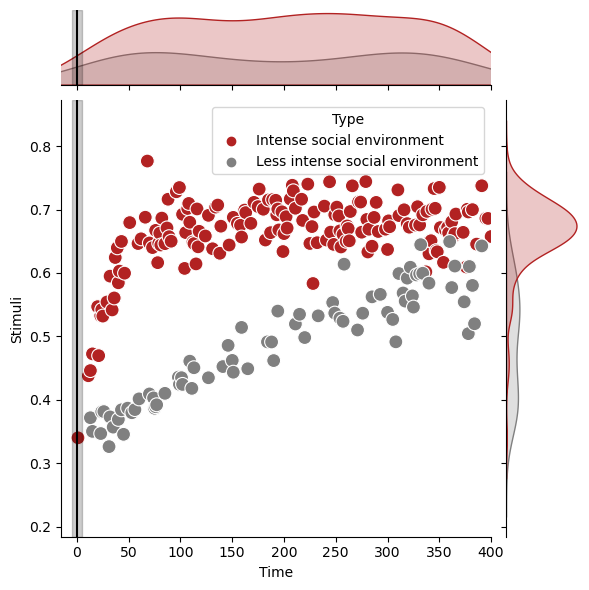

In [774]:
time = np.arange(num_steps)

# Generate random stimulus values with probability p
stimulus_high_contingency_presence = np.random.choice([0, 0.25], size=num_steps, p=[0.6, 0.4])
stimulus_low_contingency_presence = np.random.choice([0, 0.25], size=num_steps, p=[0.8, 0.2])

# Generate random intensity distributions given a lognormal distribution
mu, sigma = 1, 0.05 # mean and standard deviation
stimulus_high = np.random.lognormal(mu, sigma, num_steps)
stimulus_low = np.random.lognormal(mu, sigma, num_steps)

final_low = stimulus_low*stimulus_low_contingency_presence
final_high = stimulus_high*stimulus_high_contingency_presence

# Generate logistic growth curves
logistic_high = logistic_growth(time, 0.05)
logistic_low = logistic_growth(time, 0.005)

#Apply logistic growth in the intensity of the stimuli
final_high = logistic_high*final_high
final_low = logistic_low*final_low

visualize_sti = {"Stimuli":[],"Time":[],"Type":[],"Frequency":[],"Curve":[]}
visualize_sti["Stimuli"].extend(final_high)
visualize_sti["Curve"].extend(logistic_high)
visualize_sti["Time"].extend(time)
visualize_sti["Type"].extend(["Intense social environment"]*len(time))
visualize_sti["Frequency"].extend(stimulus_high_contingency_presence)

visualize_sti["Stimuli"].extend(final_low)
visualize_sti["Curve"].extend(logistic_low)
visualize_sti["Time"].extend(time)
visualize_sti["Type"].extend(["Less intense social environment"]*len(time))
visualize_sti["Frequency"].extend(stimulus_low_contingency_presence)

visualize_sti = pd.DataFrame(visualize_sti)
visualize_sti = visualize_sti[visualize_sti.Time<=400]
visualize_sti = visualize_sti[visualize_sti.Stimuli != 0]

g = sns.jointplot(data=visualize_sti, x="Time", y="Stimuli", hue="Type",palette=["firebrick","grey"],s=100,
                  legend = True, alpha = 1)

for ax in (g.ax_joint, g.ax_marg_x):
    ax.axvline(x = 0, color = "black",linestyle = '-')
    ax.axvspan(0 - gestation_days_sd/dt, 0 + gestation_days_sd/dt, alpha=0.2, color='black')

#plt.title("Social stimulus - s(t))")
g.ax_marg_x.set_xlim(-15,400)#400*35/60
#g.ax_marg_y.set_ylim(0.5,3)
plt.savefig("{0}/figs/5C.pdf".format(PYTHON_PATH),dpi = 800)


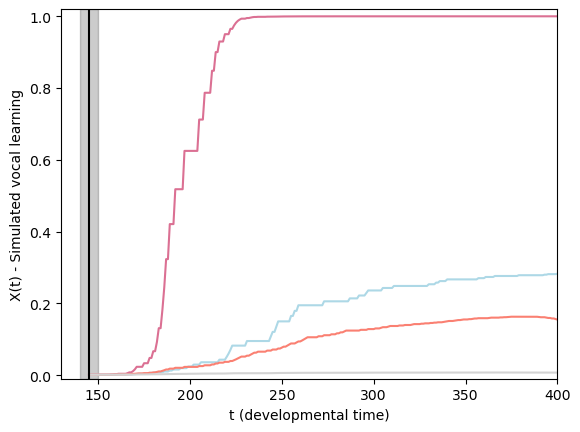

In [775]:
x0 = 0.001

stimuli = [gestation_days,400]


r = brain_plasticity_altricial
s = final_high
label = "Altricial brain + intense social environment"
color = 'palevioletred'
u, t ,ri = logistic_stimuli(x0,dt,T,s,r,A,t0 = t0,stimuli=stimuli,noise_var=noise_var)
plt.plot(t, u, color,label = label)

r = brain_plasticity_altricial
s = final_low
label = "Altricial brain + less intense social environment"
color = 'lightblue'
u, t ,ri = logistic_stimuli(x0,dt,T,s,r,A,t0 = t0,stimuli=stimuli,noise_var=noise_var)
plt.plot(t, u, color,label = label)

r = brain_plasticity_precocial
s = final_high
label = "No altricial brain + intese social environment"
color = 'salmon'
u, t ,ri = logistic_stimuli(x0,dt,T,s,r,A,t0 = t0,stimuli=stimuli,noise_var=noise_var)
plt.plot(t, u, color,label = label)

r = brain_plasticity_precocial
s = final_low
label = "No altricial brain + less intense social environment"
color = 'lightgrey'
u, t ,ri = logistic_stimuli(x0,dt,T,s,r,A,t0 = t0,stimuli=stimuli,noise_var=noise_var)
plt.plot(t, u, color,label = label)

plt.axvline(x = gestation_days, color = "black",linestyle = '-')
plt.axvspan(gestation_days - gestation_days_sd, gestation_days + gestation_days_sd, alpha=0.2, color='black')
#plt.plot(t,brain_plasticity_altricial, color='orange')

#plt.legend(loc = "upper left")
plt.ylim(-0.01,1.02)
plt.xlim(130, 400)
plt.xlabel('t (developmental time)'); plt.ylabel('X(t) - Simulated vocal learning')
plt.savefig("{0}/figs/5D.pdf".format(PYTHON_PATH),dpi = 800)
